# Reduction de dimensionnalite - Analyse en Composantes Principales (PCA)

**Branche :** `Guyjc-Modelisation`
**Auteur :** Guy Junior Calvet

## Objectif
Ce notebook applique la PCA (Principal Component Analysis) sur les donnees transformees.
La PCA est optionnelle et particulierement utile pour :
- **KNN** : reduit la malediction de la dimensionnalite
- **Modeles sensibles a la correlation** : decorrelation des features

## Pre-requis
Executer d'abord `notebook.ipynb` pour generer `donnees_transformees.npz`.

## References
- Jolliffe, I.T. (2002). *Principal Component Analysis*. Springer.
- Bellman, R. (1961). *Adaptive Control Processes*. Princeton University Press.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Bibliotheques importees.")

Bibliotheques importees.


## 1. Chargement des donnees transformees

In [2]:
# Charger les donnees transformees depuis notebook.ipynb
data = np.load('donnees_transformees.npz', allow_pickle=True)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

print(f"Donnees chargees :")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Features : {len(feature_names)}")

Donnees chargees :
  X_train : (75710, 231)
  X_test  : (18928, 231)
  Features : 231


## 2. Analyse de la variance expliquee

On analyse combien de composantes sont necessaires pour capturer un certain pourcentage de la variance.

In [3]:
# Fit PCA complet pour analyser la distribution de la variance
pca_full = PCA(random_state=2026)
pca_full.fit(X_train)

variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)

# Nombre de composantes pour differents seuils
seuils = [0.80, 0.85, 0.90, 0.95, 0.99]
print("Nombre de composantes par seuil de variance :")
for seuil in seuils:
    n_comp = np.argmax(variance_cumulee >= seuil) + 1
    print(f"  {seuil*100:.0f}% : {n_comp} composantes (compression {(1 - n_comp/X_train.shape[1])*100:.1f}%)")

Nombre de composantes par seuil de variance :
  80% : 17 composantes (compression 92.6%)
  85% : 21 composantes (compression 90.9%)
  90% : 28 composantes (compression 87.9%)
  95% : 43 composantes (compression 81.4%)
  99% : 81 composantes (compression 64.9%)


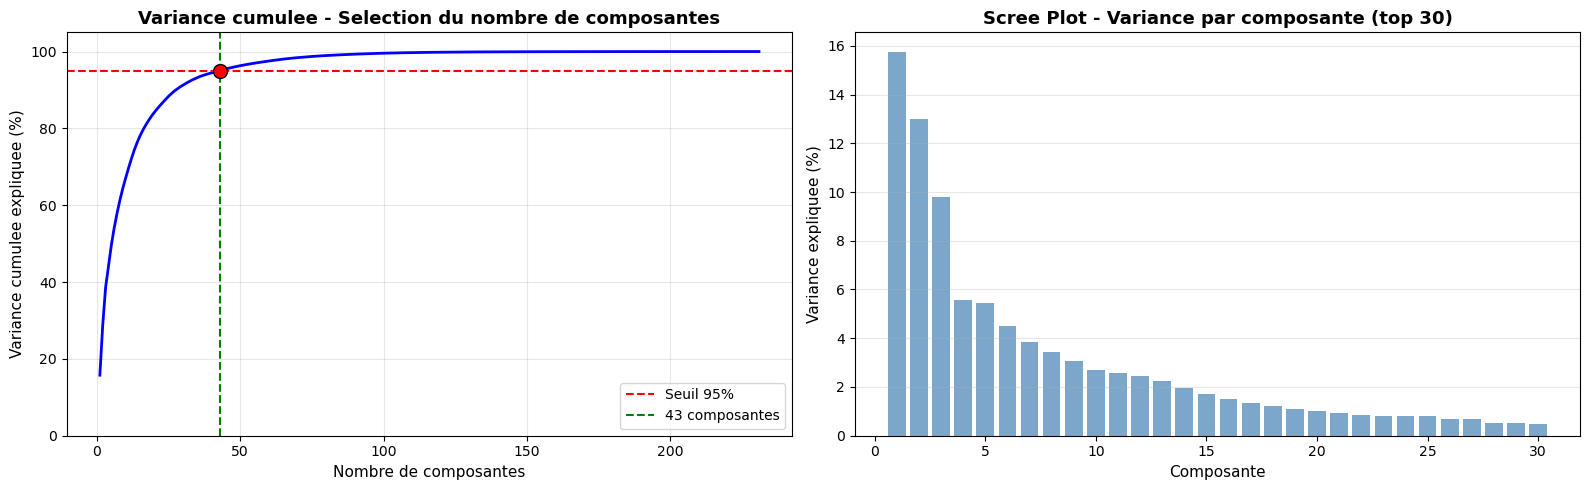


Recommandation : 43 composantes pour 95% de variance


In [4]:
# Visualisation de la variance cumulee
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique 1 : Variance cumulee
n_composantes_95 = np.argmax(variance_cumulee >= 0.95) + 1
axes[0].plot(range(1, len(variance_cumulee) + 1), variance_cumulee * 100, 'b-', linewidth=2)
axes[0].axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='Seuil 95%')
axes[0].axvline(x=n_composantes_95, color='green', linestyle='--', linewidth=1.5,
                label=f'{n_composantes_95} composantes')
axes[0].scatter([n_composantes_95], [95], color='red', s=100, zorder=5, edgecolors='black')
axes[0].set_xlabel('Nombre de composantes', fontsize=11)
axes[0].set_ylabel('Variance cumulee expliquee (%)', fontsize=11)
axes[0].set_title('Variance cumulee - Selection du nombre de composantes',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 105)

# Graphique 2 : Scree plot (variance individuelle)
axes[1].bar(range(1, min(31, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:30] * 100, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Composante', fontsize=11)
axes[1].set_ylabel('Variance expliquee (%)', fontsize=11)
axes[1].set_title('Scree Plot - Variance par composante (top 30)',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRecommandation : {n_composantes_95} composantes pour 95% de variance")

## 3. Application de la PCA (seuil 95%)

In [5]:
# Appliquer PCA avec le seuil de 95% de variance
VARIANCE_THRESHOLD = 0.95

pca = PCA(n_components=VARIANCE_THRESHOLD, random_state=2026)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Reduction de dimensionnalite :")
print(f"  Avant PCA : {X_train.shape[1]} features")
print(f"  Apres PCA : {X_train_pca.shape[1]} composantes")
print(f"  Taux de compression : {(1 - X_train_pca.shape[1]/X_train.shape[1])*100:.1f}%")
print(f"  Variance expliquee : {pca.explained_variance_ratio_.sum()*100:.2f}%")

Reduction de dimensionnalite :
  Avant PCA : 231 features
  Apres PCA : 43 composantes
  Taux de compression : 81.4%
  Variance expliquee : 95.10%


## 4. Export des donnees reduites

In [6]:
import joblib

# Export des donnees PCA
np.savez_compressed(
    'donnees_pca.npz',
    X_train_pca=X_train_pca,
    X_test_pca=X_test_pca,
    y_train=y_train,
    y_test=y_test,
    n_components=X_train_pca.shape[1],
    variance_explained=pca.explained_variance_ratio_.sum()
)

# Sauvegarder le modele PCA
joblib.dump(pca, 'pca_model.joblib')

print("Export termine :")
print("  - donnees_pca.npz (matrices numpy reduites)")
print("  - pca_model.joblib (modele PCA pour transformer de nouvelles donnees)")
print(f"\nResume :")
print(f"  X_train_pca : {X_train_pca.shape}")
print(f"  X_test_pca  : {X_test_pca.shape}")

Export termine :
  - donnees_pca.npz (matrices numpy reduites)
  - pca_model.joblib (modele PCA pour transformer de nouvelles donnees)

Resume :
  X_train_pca : (75710, 43)
  X_test_pca  : (18928, 43)


## 5. Resume

### Fichiers generes
| Fichier | Description |
|---------|-------------|
| `donnees_pca.npz` | Donnees reduites (X_train_pca, X_test_pca, y_train, y_test) |
| `pca_model.joblib` | Modele PCA entraine (pour transformer de nouvelles donnees) |

### Utilisation dans les modeles
```python
# Charger les donnees PCA
data = np.load('donnees_pca.npz')
X_train = data['X_train_pca']
X_test = data['X_test_pca']
y_train = data['y_train']
y_test = data['y_test']
```

### Modeles concernes
- **KNN** : utilise les donnees PCA
- **RandomForest** : n'a pas besoin de PCA (utilise `donnees_transformees.npz`)
- **Regression logistique** : ?